# 1. Setup and Load Data

###  1.1 Install Dependencies and Setup

In [ ]:
!pip list


In [171]:
import tensorflow as tf
import os

In [172]:
# gpus = tf.config.experimental.list_physical_devices('GPU')

In [15]:
cpus = tf.config.experimental.list_physical_devices('CPU')

In [ ]:
cpus

In [17]:
#Avoid OOM (or and out of memory) errors by setting GPU Memory Consumption Growth

gpus= tf.config.experimental.list_physical_devices('GPU')
for gpu in gpus:
    tf.config.experimental.set_memory_growth(gpu, True)

### 1.2 Remove dodgy images

In [ ]:
import sys
print(sys.executable)
print("Virtual environment:", sys.prefix != sys.base_prefix)

In [175]:
import cv2
from PIL import Image
# from matplotlib import pyplot as plt

In [176]:
data_dir = 'data'

In [178]:
image_exts = ['jpg', 'png', 'jpeg', 'bmp']

In [183]:
# plt.imshow(img)
# plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.show()

In [184]:
for img_class in os.listdir(data_dir):
    for image in os.listdir(os.path.join(data_dir, img_class)):
        image_path = os.path.join(data_dir, img_class, image)

        try:
            img = cv2.imread(image_path)
            # print(img)
            with Image.open(image_path) as pil_image:
                tip = pil_image.format.lower()
                # print(tip)
            if tip not in image_exts:
                print('image not in ext list {}'.format(image_path))
                os.remove(image_path)
        except Exception as e:
            print('issues with image {}'.format(image_path)) 
            
            

### 1.3 Load Data

In [ ]:
tf.data.Dataset??


In [185]:
import numpy as np
from matplotlib import pyplot as plt

In [186]:
data = tf.keras.utils.image_dataset_from_directory('data')

Found 392 files belonging to 2 classes.


In [187]:
data_iterator = data.as_numpy_iterator()

In [188]:
data_iterator

NumpyIterator(iterator=<tensorflow.python.data.ops.iterator_ops.OwnedIterator object at 0x0000025B3EC296D0>)

In [189]:
# get another batch from iterator
batch = data_iterator.next()

In [190]:
# Image represented as numpy arrya
batch[0].shape

(32, 256, 256, 3)

In [233]:
#Images labels 
# Class 0 = Fresh Potato 
# Class 1 = Rotten Potato 
batch[1]

array([1, 1, 0, 1, 0, 0, 0, 1], dtype=int32)

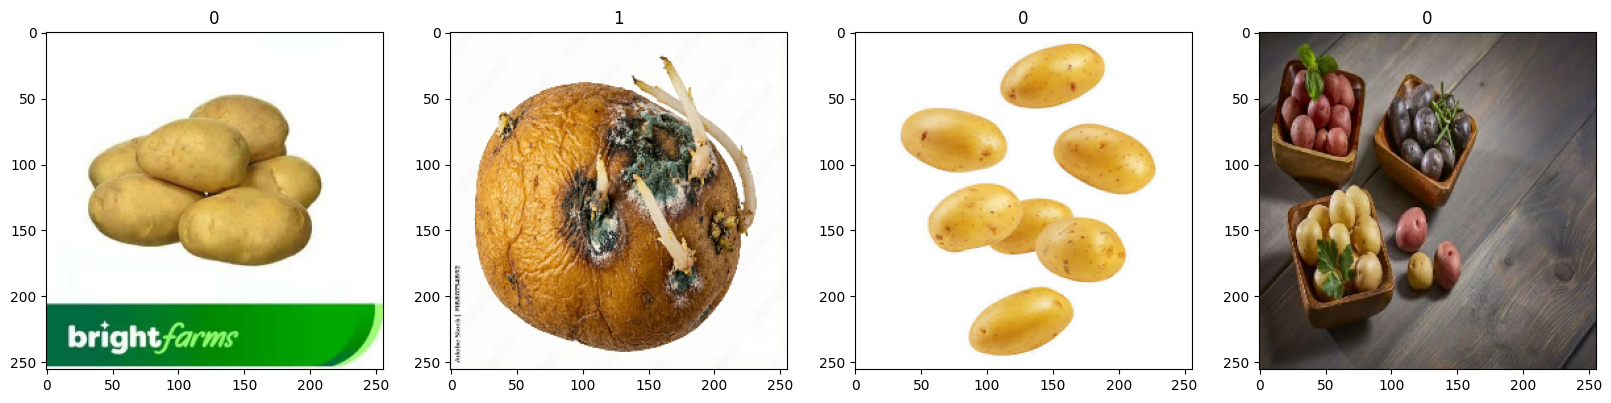

In [191]:
fig, ax = plt.subplots(ncols=4, figsize=(20,20))
for idx, img in enumerate(batch[0][:4]):
    ax[idx].imshow(img.astype(int))
    ax[idx].title.set_text(batch[1][idx])

# 2. Preprocess Data 

### 2.1 Scale Data

In [192]:
# x is Images and we preprocess data using map function
data = data.map(lambda x,y:(x/255,y))

In [193]:
scaled_iterator = data.as_numpy_iterator() 

In [194]:
batch = scaled_iterator.next()

In [ ]:
batch

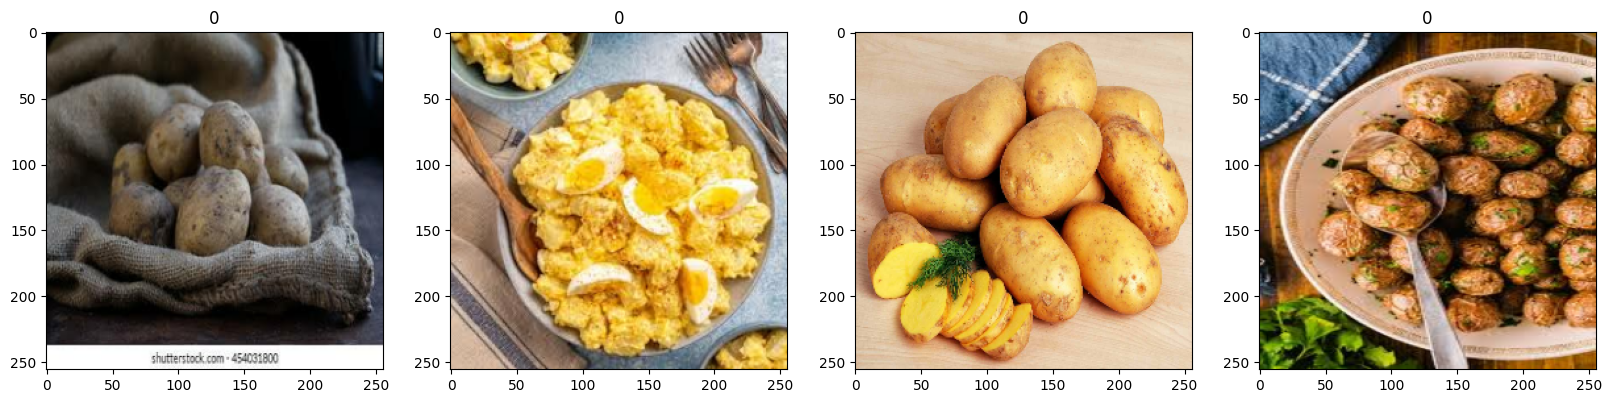

In [196]:
fig, ax = plt.subplots(ncols=4, figsize=(20,20))
for idx, img in enumerate(batch[0][:4]):
    ax[idx].imshow(img)
    ax[idx].title.set_text(batch[1][idx])

### 2.2 Split Data

In [197]:
len(data)

13

In [198]:
train_size = int(len(data)*.7)
val_size = int(len(data)*.2)
test_size = len(data) - train_size - val_size

In [199]:
train_size+val_size+test_size

13

In [200]:
train = data.take(train_size)
val = data.skip(train_size).take(val_size)
test = data.skip(train_size + val_size).take(test_size)

In [201]:
len(test)

2

## 3. Deep Learning

### 3.1 Build Deep Learning Model

In [202]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dense, Flatten
from tensorflow.keras.layers import Input

In [203]:
model = Sequential()

In [204]:
model.add(Input(shape=(256,256,3)))

model.add(Conv2D(16, (3,3), 1, activation= 'relu'))
model.add(MaxPooling2D())

model.add(Conv2D(32, (3,3), 1, activation= 'relu'))
model.add(MaxPooling2D())

model.add(Conv2D(16, (3,3), 1, activation= 'relu'))
model.add(MaxPooling2D())

model.add(Flatten())

model.add(Dense(256, activation='relu'))
model.add(Dense(1, activation= 'sigmoid'))



In [205]:
model.compile('adam', loss= tf.losses.BinaryCrossentropy(), metrics=['accuracy'])

In [206]:
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)                    │ (None, 254, 254, 16)        │             448 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_6 (MaxPooling2D)       │ (None, 127, 127, 16)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_7 (Conv2D)                    │ (None, 125, 125, 32)        │           4,640 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_7 (MaxPooling2D)       │ (None, 62, 62, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_8 (Conv2D)                    │ (None, 60, 60, 16)          │           4,624 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_8 (MaxPooling2D)       │ (None, 30, 30, 16)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_2 (Flatten)                  │ (None, 14400)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 256)                 │       3,686,656 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 1)                   │             257 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 3,696,625 (14.10 MB)

 Trainable params: 3,696,625 (14.10 MB)

 Non-trainable params: 0 (0.00 B)

### 3.2 Train

In [207]:
logdir = 'logs'

In [208]:
tensorboard_callback = tf.keras.callbacks.TensorBoard(log_dir = logdir)

In [209]:
hist = model.fit(train,epochs=20, validation_data=val, callbacks=[tensorboard_callback])

Epoch 1/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 12s 678ms/step - accuracy: 0.6944 - loss: 0.7050 - val_accuracy: 0.7969 - val_loss: 0.4691
Epoch 2/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 7s 711ms/step - accuracy: 0.7743 - loss: 0.4394 - val_accuracy: 0.7188 - val_loss: 0.4249
Epoch 3/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 7s 698ms/step - accuracy: 0.7778 - loss: 0.4291 - val_accuracy: 0.7344 - val_loss: 0.4205
Epoch 4/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 7s 697ms/step - accuracy: 0.7812 - loss: 0.3912 - val_accuracy: 0.8594 - val_loss: 0.3214
Epoch 5/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 7s 720ms/step - accuracy: 0.8368 - loss: 0.3642 - val_accuracy: 0.9375 - val_loss: 0.3069
Epoch 6/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 7s 723ms/step - accuracy: 0.8438 - loss: 0.3123 - val_accuracy: 0.8438 - val_loss: 0.3049
Epoch 7/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 7s 698ms/step - accuracy: 0.8889 - loss: 0.2318 - val_accuracy: 0.9062 - val_loss: 0.2147
Epoch 8/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 7s 680ms/step - accuracy: 0.9618 - loss: 0.1752 - val_accuracy: 0.9531 - val_loss

In [ ]:
hist.history

### 3.3 Plot Performance

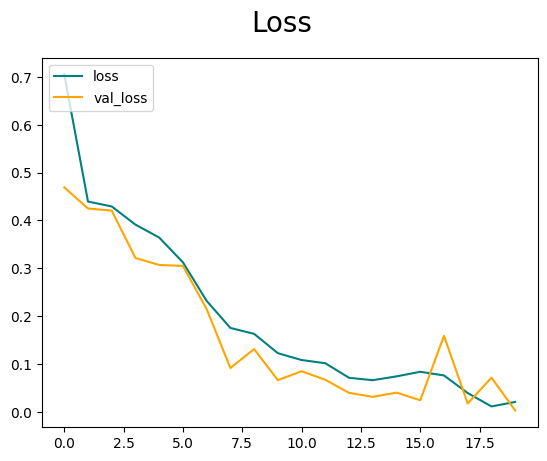

In [216]:
fig = plt.figure()
plt.plot(hist.history['loss'], color= 'teal', label= 'loss')
plt.plot(hist.history['val_loss'], color= 'orange', label= 'val_loss')
fig.suptitle('Loss', fontsize=20)
plt.legend(loc= 'upper left')
plt.show()

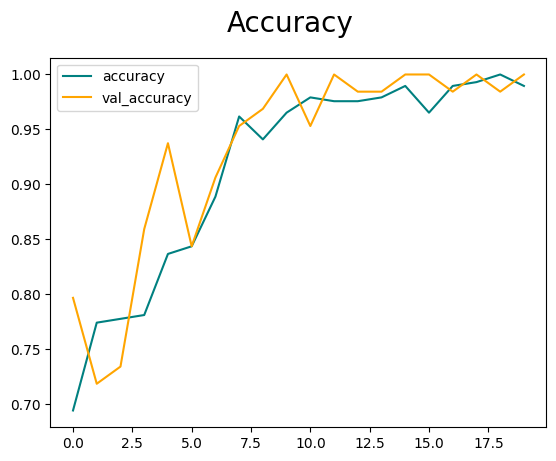

In [217]:
fig = plt.figure()
plt.plot(hist.history['accuracy'], color= 'teal', label= 'accuracy')
plt.plot(hist.history['val_accuracy'], color= 'orange', label= 'val_accuracy')
fig.suptitle('Accuracy', fontsize=20)
plt.legend(loc= 'upper left')
plt.show()

# 4. Performance

### 4.1 Evaluate

In [219]:
from tensorflow.keras.metrics import Precision, Recall, BinaryAccuracy

In [222]:
pre = Precision()
re = Recall()
acc = BinaryAccuracy()

In [224]:
for batch in test.as_numpy_iterator():
    X, y = batch
    yhat = model.predict(X)
    pre.update_state(y, yhat)
    re.update_state(y, yhat)
    acc.update_state(y, yhat)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 688ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 351ms/step


In [225]:
print(f'Precision:{pre.result().numpy()}, Recall:{re.result().numpy()}, Accuracy:{acc.result().numpy()}')

Precision:1.0, Recall:1.0, Accuracy:1.0


#### 4.2 Test

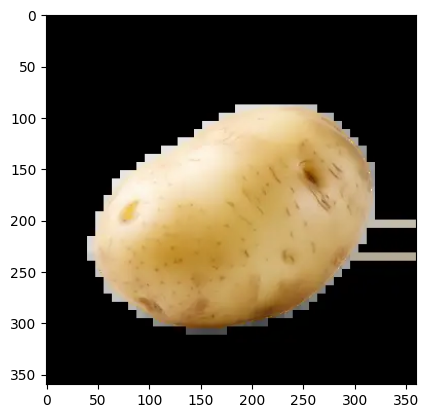

In [242]:
img = cv2.imread('fresh_test_1.png')
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.show()

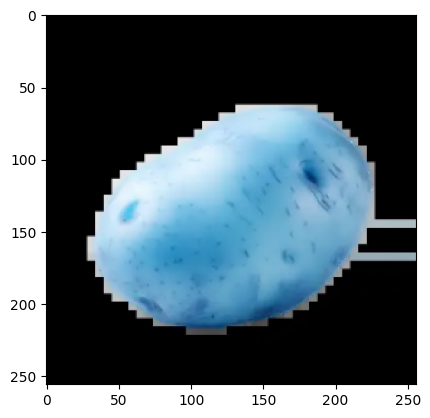

In [243]:
resize = tf.image.resize(img, (256,256))
plt.imshow(resize.numpy().astype(int))
plt.show()

In [244]:
scaled_image = resize/255   # Scale pixels from 0–255 to 0–1
image_batch = np.expand_dims(scaled_image, 0)  #make a batch of one image
yhat = model.predict(image_batch)  #Ask trained model to rpedict

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 143ms/step


In [245]:
yhat

array([[0.49656403]], dtype=float32)

In [246]:
if yhat > 0.5:
    print(f'Predicted class is Rotten Potatoe')
else:
    print(f'Predicted class is Fresh Potatoe')

Predicted class is Fresh Potatoe


# 5. Save the Model

### 5.1 Save the Model

In [249]:
from tensorflow.keras.models import load_model

In [ ]:
model.save(os.path.join('models', 'freshRottenmodel.h5'))

In [ ]:
new_model = load_model(os.path.join('models', 'freshRottenmodel.h5'))

In [252]:
yhatnew = new_model.predict(np.expand_dims(resize/255,0))

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 707ms/step


In [253]:
if yhatnew > 0.5:
    print(f'Predicted class is Rotten Potatoe')
else:
    print(f'Predicted class is Fresh Potatoe')

Predicted class is Fresh Potatoe
